In [1]:
from langgraph.graph import START ,END , StateGraph
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict

d:\Clg Kabir_\Agentic-AI\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()


True

In [9]:
class SubState(TypedDict):
    input_text:str
    translated_text:str
    

In [10]:
subgraph_llm=ChatGroq(model='llama-3.3-70b-versatile')

In [11]:
def translate_text(state:StateGraph):
    prompt=f"""
    Translate the following text into Hindi .
    Keep it natural clear and dont add additional content.

    TEXT:{state['input_str']}    
""".strip()

    translate_text=subgraph_llm.invoke(prompt).content
    return {"translated_text":translate_text}

In [12]:
subgraph=StateGraph(SubState)

subgraph.add_node("Translator",translate_text)
subgraph.add_edge(START,"Translator")
subgraph.add_edge("Translator",END)

translator=subgraph.compile()


In [13]:
class ParentState(TypedDict):
    question :str
    answer_eng :str
    answer_hindi:str
    

In [15]:
parent_llm=ChatGroq(model='llama-3.3-70b-versatile')


In [14]:
def generate_answer(state:ParentState):
    answer=parent_llm.invoke(f"""You are a helpul assistant . Answer clearly.
    Question :{state['question']}""").content
    return {'answer_end':answer}

In [18]:
def translate_answer(state:ParentState):
    # Calling Subgraph
    result=translator.invoke({'input_text': state['asnwer_eng']})
    return {'answer_hindi':result['translated_text']}


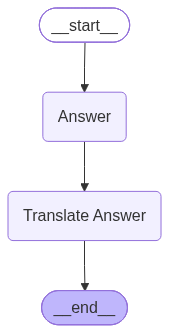

In [19]:
parentgraph=StateGraph(ParentState)

parentgraph.add_node("Answer",generate_answer)
parentgraph.add_node("Translate Answer",translate_answer)

parentgraph.add_edge(START,'Answer')
parentgraph.add_edge("Answer","Translate Answer")
parentgraph.add_edge("Translate Answer",END)

graph=parentgraph.compile()
graph